In [ ]:
import math
import numpy as np
import jax
from jax import Array
import jax.numpy as jnp
from numpy.linalg import matrix_power
import matplotlib.pyplot as plt
from jax.scipy.special import xlogy
jax.config.update('jax_enable_x64', True)

def matrix_powers(G, N):
  def step(Gk, _):
    return Gk @ G, Gk

  _, Gs = jax.lax.scan(
    step,
    init=jnp.eye(G.shape[0], dtype=G.dtype),
    xs=None,
    length=N,
  )
  return Gs  # [I, G, G^2, ..., G^(N-1)]

# ---- entropy and KL divergence use convention that 0 log 0 = 0
def H(p):
  return - jnp.sum(jnp.where(p==0, 0.0, p * jnp.log(p)))

def KL(p, q):
  return jnp.sum(jnp.where(p==0, 0.0, xlogy(p,p) - xlogy(p,q)))

# ---- optimal prior
def get_q_star(p: Array, G: Array, n_steps: Array):
  Gs = matrix_powers(G, N)
  traj = jax.vmap(lambda G_i: G_i @ p)(Gs)
  return jnp.mean(traj, axis=0)

def pop(p0, G, N, *, use_mat_power: bool=True):
  p_avg = np.zeros_like(p0, dtype=float)
  
  # sparse matrices font work with mat power
  if use_mat_power:
    for t in range(0, N):
      p_avg += matrix_power(G, t) @ p0
  else:
    p = p0.copy()
    for _ in range(N):
      p_avg += p
      p = G @ p

  return p_avg / N

def pmmc(p0, G, N):
  p_avg = pop(p0, G, N)
  return (
    H(matrix_power(G, N) @ p0) - H(p0) + N * (H(p_avg) - H(G @ p_avg))
  )


def pmmc2(p0, G, N):
  p0 = jnp.asarray(p0, dtype=jnp.float32)

  if N == 0:
    return 0.0

  p = p0.copy()

  def body(i, carry):
    p_avg, p = carry
    p_avg = p_avg + p
    return (p_avg, G @ p)

  p_avg, p = jax.lax.fori_loop(0, N, body, (jnp.zeros_like(p0), p))
  p_avg = p_avg / N

  return H(p) - H(p0) + N * (H(p_avg) - H(G @ p_avg))


def JS(distributions, base=jnp.e):
  P = jnp.asarray(distributions, dtype=jnp.float32)
  P /= P.sum(axis=1, keepdims=True)
  N = P.shape[0]
  return N * H(P.mean(axis=0)) - jnp.sum(jax.vmap(H)(P))

In [ ]:
# simple DFA

Ns = np.arange(1,20)

p=0.8

p0 = np.array([1, 0])
G = np.array([
    [p, 0],
    [1-p, 1],
])
simple_pmmc = np.array([pmmc(p0,G,N) for N in Ns])

p0 = np.array([1, 0, 0])
G = np.array([
  [p,   0,   0],
  [1-p, 1-p, 1-p],
  [0,   p,   p]
])
extra_pmmc = np.array([pmmc(p0,G,N) for N in Ns])

p0 = np.array([1, 0, 0, 0])
G = np.array([
  [p,   0,   0,   0],
  [1-p, 1-p, 0,   p],
  [0,   p,   1-p, 0],
  [0,   0,   p,   1-p]
])
four_state_pmmc = [pmmc(p0, G, N) for N in Ns]

p0 = np.array([1, 0, 0, 0, 0, 0])

G = np.array([
    [p,   0,   0,   0,   0,   0],
    [1-p, 1-p, 0,   0,   0,   p],
    [0,   p,   1-p, 0,   0,   0],
    [0,   0,   p,   1-p, 0,   0],
    [0,   0,   0,   p,   1-p, 0],
    [0,   0,   0,   0,   p,   1-p]
])

five_state_pmmc = np.array([
    pmmc(p0, G, N)
    for N in Ns
])

plt.plot(Ns, simple_pmmc, label="1 accepting state")
plt.plot(Ns, extra_pmmc, label="2 accepting states")
plt.plot(Ns, four_state_pmmc, label="3 accepting states")
plt.plot(Ns, five_state_pmmc, label="5 accepting states")

plt.xlabel("$N$")
plt.ylabel("Periodic Minimum MMC")
plt.legend()
plt.show()


In [ ]:
# Probability of reading a 0
p = 0.7
q = 1 - p

# 20-state DFA

n = 20
G20 = np.zeros((n, n))

# States:
# 0-4   : A1-A5
# 5-9   : B1-B5
# 10-14 : C1-C5
# 15-19 : D1-D5

for i in range(5):
  nxt = (i + 1) % 5

  # ---------- A ----------
  G20[nxt, i] += p            # A_i --0--> A_{i+1}
  G20[5 + nxt, i] += (1 - p)          # A_i --1--> B_{i+1}

  # ---------- B ----------
  G20[10 + nxt, 5 + i] += p       # B_i --0--> C_{i+1}
  G20[5 + nxt, 5 + i] += (1 - p)       # B_i --1--> B_{i+1}

  # ---------- C ----------
  G20[nxt, 10 + i] += p         # C_i --0--> A_{i+1}
  G20[15 + nxt, 10 + i] += (1 - p)     # C_i --1--> D_{i+1}

  # ---------- D ----------
  G20[15 + i, 15 + i] += p      # D_i --0--> D_{i+1}
  G20[15 + i, 15 + i] += (1 - p)     # D_i --1--> D_{i+1}

# Minimal 4-state DFA

G4 = np.array([
    [p,   0,   p,   0],
    [q,   q,   0,   0],
    [0,   p,   0,   0],
    [0,   0,   q,   1]
], dtype=float)

Ns=np.arange(1,50)

p0 = np.concatenate((np.array([1]), np.zeros(19)))
G20_mmc = np.array([
    pmmc(p0, G20, N)
    for N in Ns
])

p0=[1,0,0,0]
G4_mmc = np.array([
    pmmc(p0, G4, N)
    for N in Ns
])


In [ ]:
plt.plot(Ns, G4_mmc, color='red', label='minimal')
plt.plot(Ns, G20_mmc, color='blue', label='original')
plt.legend()

In [ ]:
Ns = np.arange(0,25)

p0 = np.array([1,0,0,0])
traj = [matrix_power(G4,t) @ p0 for t in Ns]
qstartraj = [pop(p0,G4,N) for N in Ns]

fig, ax = plt.subplots(5,5, figsize=(10,10), layout='tight')
ax = ax.flatten()

for j, N in enumerate(Ns):
    ax[j].bar(range(0,4), traj[j], alpha=0.8, label=rf"$p_{j}$")
    #ax[j].bar(range(0,4), qstartraj[j], alpha=0.8, label=r"$q^*$")
    ax[j].set_title(rf"$N={N}$")
    ax[j].set_ylim(0,1)
    ax[j].legend()

In [ ]:
Ns = range(1, 21)
p0 = np.array([1, 0, 0, 0])

traj_term1 = [
    JS([matrix_power(G4, t) @ p0 for t in range(N)])
    for N in Ns
]

traj_term2 = [
    JS([matrix_power(G4, t + 1) @ p0 for t in range(N)])
    for N in Ns
]

plt.plot(Ns, traj_term1, label="0,...,N-1")
plt.plot(Ns, traj_term2, label="1,...,N")
plt.plot(Ns, np.array(traj_term1)-np.array(traj_term2), label="1,...,N")
plt.ylim(0,25)
plt.legend()

In [ ]:
plt.rcParams['text.usetex'] = False

Ns = np.arange(0,25)
p0 = np.concatenate((np.array([1]), np.zeros(19)))
traj = [matrix_power(G20,t) @ p0 for t in Ns]
qstartraj = [pop(p0,G20,N) for N in Ns]

fig, ax = plt.subplots(5,5, figsize=(10,10), layout='tight')
ax = ax.flatten()

for j, N in enumerate(Ns):
  ax[j].bar(range(0,20), traj[j], alpha=0.8, label=rf"$p_{j}$")
  #ax[j].bar(range(0,20), qstartraj[j], alpha=0.8, label=r"$q^*$")
  ax[j].set_title(rf"$N={N}$")
  ax[j].set_ylim(0,1)
  ax[j].legend()

In [ ]:
Ns = range(1, 21)
p0 = np.concatenate((np.array([1]), np.zeros(19)))

traj_term1 = [
    JS([matrix_power(G20, t) @ p0 for t in range(N)])
    for N in Ns
]

traj_term2 = [
    JS([matrix_power(G20, t + 1) @ p0 for t in range(N)])
    for N in Ns
]

plt.plot(Ns, traj_term1, label="0,...,N-1")
plt.plot(Ns, traj_term2, label="1,...,N")
plt.plot(Ns, np.array(traj_term1) - np.array(traj_term2))
plt.ylim(0,25)
plt.legend()

In [ ]:
from typing import Any
from itertools import product
from time import perf_counter
import scipy.sparse as sp

# treat each spin config as an integer state in 0,...,2^{N-1} => N bits

# - bit position of site -> each bit can be in (0, 1) representing spin up or down
# - site 0 corresponds to leftmost bit
def bitpos(site, N):
  return N - 1 - site

def spin(state, site, N):
  b = bitpos(site, N)
  # right-shift by b bits, putting the value of the site in the rightmost bit
  # then, & with 1 to check if 1 or 0
  return 1 if (state >> b) & 1 else -1

def flip(state, site, N):
  b = bitpos(site, N)
  return state ^ (1 << b)

def decode_state(state, N):
  return tuple(spin(state, site, N) for site in range(N))

##############################################################################
# Generate the Glauber/Metropolis transition matrix
##############################################################################

def compute_site_neighbors(shape=(2,2)):
  Lx, Ly = shape
  N = Lx * Ly

  # Nearest-neighbor pairs
  site_neighbors = [[] for _ in range(N)]
  for x in range(Lx):
    for y in range(Ly):
      i = x * Ly + y
      if x + 1 < Lx:
        j = i + Ly
        site_neighbors[i].append(j)
        site_neighbors[j].append(i)

      if y + 1 < Ly:
        j = i + 1
        site_neighbors[i].append(j)
        site_neighbors[j].append(i)

  return site_neighbors


def generate_glauber_matrix_bits(shape=(2,2), J=1.0, h=0.1, beta=1.0):
  N = math.prod(shape)
  nstates = 1 << N
  site_neighbors = compute_site_neighbors(shape)
  masks = [1 << (N - 1 - site) for site in range(N)]


  # Hamiltonian  
  # def H(state: int):
  #   interaction = 0.0
  #   for i, j in neighbors:
  #     interaction += spin(state, i, N) * spin(state, j, N)

  #   # field = sum(state)
  #   field = 2 * state.bit_count() - N
  #   return -J * interaction - h * field

  # Build transition matrix
  rows = []
  cols = []
  data = []

  # index here is column
  for σ in range(nstates):
    # energy for state σ
    stay_prob = 1.0

    # flip each site
    for site, mask in enumerate(masks):
      s_i = 1 if σ & mask else -1
      nb_sum = 0
      for j in site_neighbors[site]:
        nb_sum += 1 if σ & masks[j] else -1

      dE = 2 * s_i * (J * nb_sum + h)
      # integer value of η is the row of the matrix
      η = σ ^ mask
      # Metropolis acceptance probability / N
      # q(σ,eta)=1/N
      prob = np.exp(-beta * dE) / N

      rows.append(η)
      cols.append(σ)
      data.append(prob)
      stay_prob -= prob
    
    rows.append(σ)
    cols.append(σ)
    data.append(stay_prob)

  return sp.coo_matrix((data, (rows, cols)), shape=(nstates, nstates)).tocsr()



def generate_glauber_matrix(shape=(2,2), J=1.0, h=0.1, beta=1.0):
  """
  Returns the transition matrix G for the Ising model with
  Metropolis Glauber dynamics.

  Parameters
  ----------
  shape : tuple
      Lattice dimensions, e.g. (2,2), (3,3), etc.
  J : float
      Ferromagnetic coupling.
  h : float
      External magnetic field.
  beta : float
      Inverse temperature.

  Returns
  -------
  G : ndarray
      Column-stochastic transition matrix.
      p_{t+1} = G @ p_t
  states : list
      List of spin configurations.
  """

  Lx, Ly = shape
  N = Lx * Ly
  nstates = 1 << N


  # Nearest-neighbor pairs
  neighbors = []
  # i = np.stack(np.meshgrid(np.arange(Lx), np.arange(Ly)), axis=-1)
  for x in range(Lx):
    for y in range(Ly):
      i = x * Ly + y
      if x + 1 < Lx:
        neighbors.append((i, i + Ly))

      if y + 1 < Ly:
        neighbors.append((i, i + 1))

  # Hamiltonian
  def _H(state):
    interaction = 0.0
    for i, j in neighbors:
      interaction += state[i] * state[j]

    field = sum(state)

    return -J * interaction - h * field


  # Enumerate every spin configuration
  # t0 = perf_counter()
  # {-1, +1}^N
  states = list(product([-1, 1], repeat=N))
  # print(perf_counter() - t0)
  # print(states)
  index = {state: i for i, state in enumerate(states)}

  # t0 = perf_counter()
  # states_bits = tuple(range(nstates))
  # print(perf_counter() - t0)
  # print([decode_state(state, N) for state in states_bits])

  # energies
  Es = np.array([_H(s) for s in states])
  # print(Es)

  # Build transition matrix
  G = np.zeros((nstates, nstates))

  for col, sigma in enumerate(states):

    E_sigma = Es[col]
    stay_prob = 1.0

    sigma = list(sigma)

    # flip each site
    for site in range(N):
      eta = sigma.copy()
      eta[site] *= -1
      eta = tuple(eta)

      row = index[eta]

      dE = Es[row] - E_sigma

      # Metropolis acceptance probability
      accept = np.exp(-beta * max(dE, 0))

      # q(sigma,eta)=1/N
      prob = accept / N

      G[row, col] = prob
      stay_prob -= prob

    G[col, col] = stay_prob

  return G#, states


def make_interaction_graph(shape=(4, 4)):
  # build on host, output jax arrays
  Lx, Ly = shape
  N = Lx * Ly
  nstates = 1 << N

  # each amsk has exactly one bit set, corresponding to the lattice site
  masks = np.array([1 << (N - 1 - site) for site in range(N)], dtype=np.int64)
  # ^ XOR --> σ^mask flips the bit at the site
  # rows[site, σ] = σ ^ masks[site]
  rows = jnp.array([np.arange(nstates, dtype=np.int64) ^ mask for mask in masks], dtype=jnp.int64)

  # get the neighbors for each site 
  site_neighbors = compute_site_neighbors(shape)
  # enumerate all 2^N states
  states = np.arange(nstates, dtype=np.int64)
  spins = np.where((states[None, :] & masks[:, None]) != 0, 1.0, -1.0)
  spins = jnp.asarray(spins)

  nb_sum = np.zeros((N, nstates), dtype=np.float32)
  for site in range(N):
    for j in site_neighbors[site]:
      nb_sum[site] += spins[j]

  nb_sum = jnp.asarray(nb_sum)

  dE_J = (2.0 * spins * nb_sum).astype(jnp.float32)
  dE_h_sign = (2.0 * spins).astype(jnp.float32)
  return rows, dE_J, dE_h_sign


def apply_glauber(p, rows: Array, dE_J, dE_h_sign, beta, h, J=1.0):
  N = rows.shape[0]
  dE = J * dE_J + h * dE_h_sign

  # flip probability
  # off = jnp.exp(-beta * jnp.maximum(dE, 0.0)) / N
  flip_prob = jax.nn.sigmoid(-beta * dE) / N

  # prob of remaining in original state
  diag = 1.0 - flip_prob.sum(axis=0)

  p_next = diag * p
  
  def body(site, res):
    # rows[site, sigma] is sigma with site flipped.
    incoming = (flip_prob[site] * p)[rows[site]]
    return res + incoming
    
  # go through flipping each of N sites
  return jax.lax.fori_loop(0, N, body, p_next)


def pmmc_kernel(p0, graph, beta, h, Nsteps):
  rows, dE_J, dE_h_sign = graph
  p0 = jnp.asarray(p0)

  def body(_, carry):
    p, p_avg = carry
    return (
      apply_glauber(p, rows, dE_J, dE_h_sign, beta, h),
      p_avg + p,
    )

  p, p_avg = jax.lax.fori_loop(
    0,
    Nsteps,
    body,
    (p0, jnp.zeros_like(p0)),
  )

  p_avg = p_avg / Nsteps
  Gp_avg = apply_glauber(p_avg, rows, dE_J, dE_h_sign, beta, h)

  return H(p) - H(p0) + Nsteps * (H(p_avg) - H(Gp_avg))



## CURRENT VERSION

In [ ]:
# Number of steps to include in the cumulative MMC
Nsteps = 50

J = 1.0

# critical temperature
T_c = 2 * J / np.log(1 + np.sqrt(2))

shape = (2, 2)
N = math.prod(shape)
p0 = jnp.ones((1 << N)) / (1 << N)

graph = make_interaction_graph(shape=shape, J=J)
graph_jax = tuple(map(jnp.asarray, graph))

print(apply_glauber(p0, *graph_jax, 1.0, 0.5))

[0.11907177 0.04805884 0.04805884 0.0625     0.04805884 0.0625
 0.00338242 0.07694116 0.04805883 0.00338242 0.0625     0.07694116
 0.0625     0.07694116 0.07694116 0.1241634 ]


Finished tracing convert_element_type for jit in 0.004379034 sec
Compiling jit(convert_element_type) with global shapes and types (ShapedArray(float32[50]),). Argument mapping: (UnspecifiedValue,).
Finished jaxpr to MLIR module conversion jit(convert_element_type) in 0.029115915 sec
Finished XLA compilation of jit(convert_element_type) in 0.035564899 sec
Finished tracing dynamic_slice for jit in 0.000445843 sec
Compiling jit(dynamic_slice) with global shapes and types (ShapedArray(float32[50]), ShapedArray(int64[], weak_type=True)). Argument mapping: (UnspecifiedValue, UnspecifiedValue).
Finished jaxpr to MLIR module conversion jit(dynamic_slice) in 0.009798288 sec
Finished XLA compilation of jit(dynamic_slice) in 0.039801121 sec
Finished tracing pmmc_eval for jit in 0.031332970 sec
Compiling jit(pmmc_eval) with global shapes and types (ShapedArray(float32[]), ShapedArray(float32[])). Argument mapping: (UnspecifiedValue, UnspecifiedValue).
Finished jaxpr to MLIR module conversion jit(p

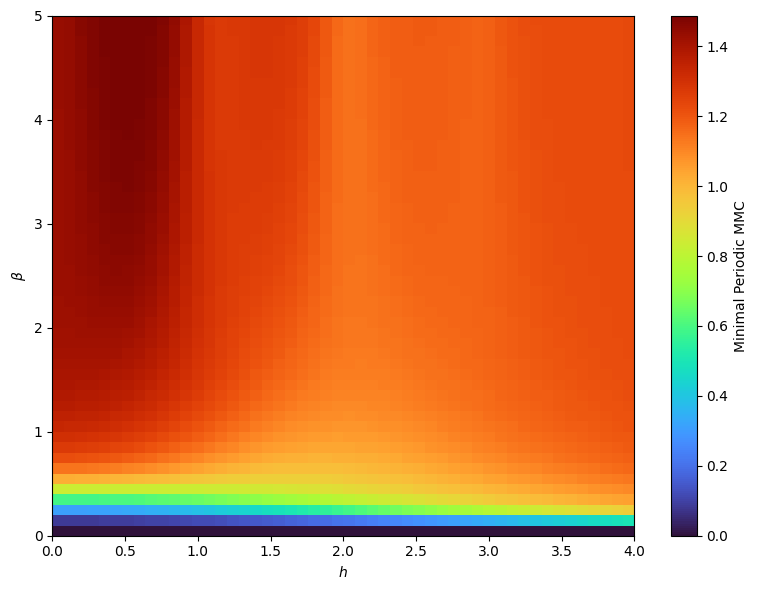

In [ ]:
# Parameter ranges
h_vals = jnp.linspace(0, 4, 50)
beta_vals = jnp.linspace(0, 5, 50)

# Number of steps to include in the cumulative MMC
Nsteps = 50

J = 1.0

# critical temperature
T_c = 2 * J / np.log(1 + np.sqrt(2))
print(T_c)

shape = (4, 4)
N = math.prod(shape)
p0 = jnp.ones((1 << N)) / (1 << N)

graph = make_interaction_graph(shape=shape, J=J)
graph_jax = tuple(map(jnp.asarray, graph))

print(pmmc_kernel(p0, graph_jax, 1.0, 1.0, Nsteps))

@jax.jit
def pmmc_eval(beta, h):
  return pmmc_kernel(p0, graph_jax, beta, h, Nsteps)

@jax.jit
def pmmc_row(beta, h_vals):
  return jax.lax.map(lambda h: pmmc_eval(beta, h), h_vals)

_ = pmmc_eval(beta_vals[0], h_vals[0]).block_until_ready()  # one compile

heatmap = np.empty((len(beta_vals), len(h_vals)), dtype=np.float32)
for i, beta in enumerate(beta_vals):
  heatmap[i] = np.asarray(pmmc_row(beta, h_vals))

# for i, beta in enumerate(beta_vals):
#   for j, h in enumerate(h_vals):
#     heatmap[i, j] = pmmc_eval(beta, h)

# inner_vmap = jax.vmap(pmmc_eval, in_axes=(None, 0))
# grid_vmap = jax.vmap(inner_vmap, in_axes=(0, None))

# heatmap = grid_vmap(beta_vals, h_vals)


# for i, beta in enumerate(beta_vals):
#   for j, h in enumerate(h_vals):
#     G = make_glauber(h, beta)
#     # cumulative MMC
#     heatmap[i, j] = pmmc2(p0, G, Nsteps)
    # print(f"Finished beta = {beta:.2f}")

fig, ax = plt.subplots(1, 1, figsize=(8,6), squeeze=True)
ax.imshow(
  heatmap,
  origin='lower',
  extent=[h_vals[0], h_vals[-1], beta_vals[0], beta_vals[-1]],
  aspect='auto',
  cmap='turbo'
)
ax.set(xlabel=r"$h$", ylabel=r"$\beta$")
plt.colorbar(label=r"Minimal Periodic MMC")
plt.tight_layout()
plt.show()

Finished tracing _linspace for jit in 0.009142160 sec
Compiling jit(_linspace) with global shapes and types (ShapedArray(int64[], weak_type=True), ShapedArray(int64[], weak_type=True)). Argument mapping: (UnspecifiedValue, UnspecifiedValue).
Finished jaxpr to MLIR module conversion jit(_linspace) in 0.017207146 sec
Finished XLA compilation of jit(_linspace) in 0.085582733 sec
Finished tracing convert_element_type for jit in 0.000190020 sec
Compiling jit(convert_element_type) with global shapes and types (ShapedArray(float64[]),). Argument mapping: (UnspecifiedValue,).
Finished jaxpr to MLIR module conversion jit(convert_element_type) in 0.002862692 sec
Finished XLA compilation of jit(convert_element_type) in 0.005194902 sec
Finished tracing broadcast_in_dim for jit in 0.000257969 sec
Compiling jit(broadcast_in_dim) with global shapes and types (ShapedArray(float64[]),). Argument mapping: (UnspecifiedValue,).
Finished jaxpr to MLIR module conversion jit(broadcast_in_dim) in 0.003093958 

TypeError: FigureBase.colorbar() missing 1 required positional argument: 'mappable'

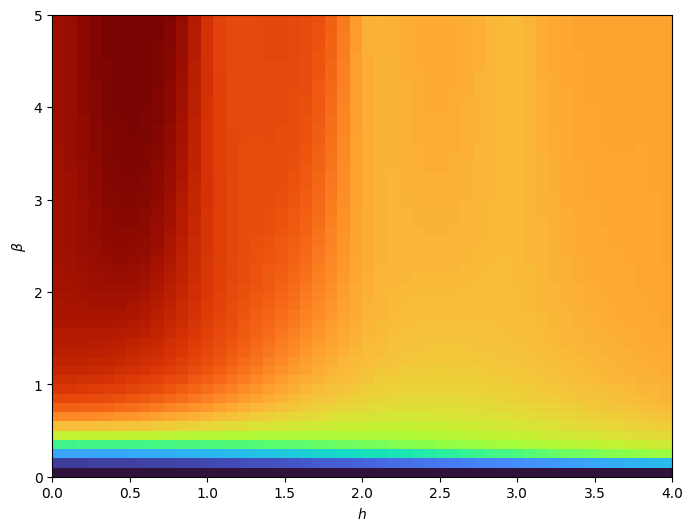

In [ ]:
jax.config.update('jax_log_compiles', True)
# Parameter ranges
h_vals = jnp.linspace(0, 4, 50)
beta_vals = jnp.linspace(0, 5, 50)

# Number of steps to include in the cumulative MMC
Nsteps = 30


shape = (4, 4)
N = math.prod(shape)
p0 = jnp.ones((1 << N)) / (1 << N)

graph = make_interaction_graph(shape=shape)
graph_jax = tuple(jnp.asarray(x) for x in graph)

@jax.jit
def pmmc_eval(beta, h):
  return pmmc_kernel(p0, graph_jax, beta, h, Nsteps)

@jax.jit
def pmmc_row(beta, h_vals):
  return jax.lax.map(lambda h: pmmc_eval(beta, h), h_vals)

_ = pmmc_eval(beta_vals[0], h_vals[0]).block_until_ready()  # one compile

heatmap = np.empty((len(beta_vals), len(h_vals)), dtype=np.float32)
for i, beta in enumerate(beta_vals):
  heatmap[i] = np.asarray(pmmc_row(beta, h_vals))

# for i, beta in enumerate(beta_vals):
#   for j, h in enumerate(h_vals):
#     heatmap[i, j] = pmmc_eval(beta, h)

# inner_vmap = jax.vmap(pmmc_eval, in_axes=(None, 0))
# grid_vmap = jax.vmap(inner_vmap, in_axes=(0, None))

# heatmap = grid_vmap(beta_vals, h_vals)


# for i, beta in enumerate(beta_vals):
#   for j, h in enumerate(h_vals):
#     G = make_glauber(h, beta)
#     # cumulative MMC
#     heatmap[i, j] = pmmc2(p0, G, Nsteps)
    # print(f"Finished beta = {beta:.2f}")

fig, ax = plt.subplots(1, 1, figsize=(8,6), squeeze=True)
ax.imshow(
  heatmap,
  origin='lower',
  extent=[h_vals[0], h_vals[-1], beta_vals[0], beta_vals[-1]],
  aspect='auto',
  cmap='turbo'
)
ax.set(xlabel=r"$h$", ylabel=r"$\beta$")
fig.colorbar(label=r"Minimal Periodic MMC")
plt.tight_layout()
plt.show()

Finished tracing pmmc_eval for jit in 0.009298325 sec
Compiling jit(pmmc_eval) with global shapes and types (ShapedArray(float32[]), ShapedArray(float32[])). Argument mapping: (UnspecifiedValue, UnspecifiedValue).
Finished jaxpr to MLIR module conversion jit(pmmc_eval) in 0.036150932 sec
Finished XLA compilation of jit(pmmc_eval) in 0.324190855 sec


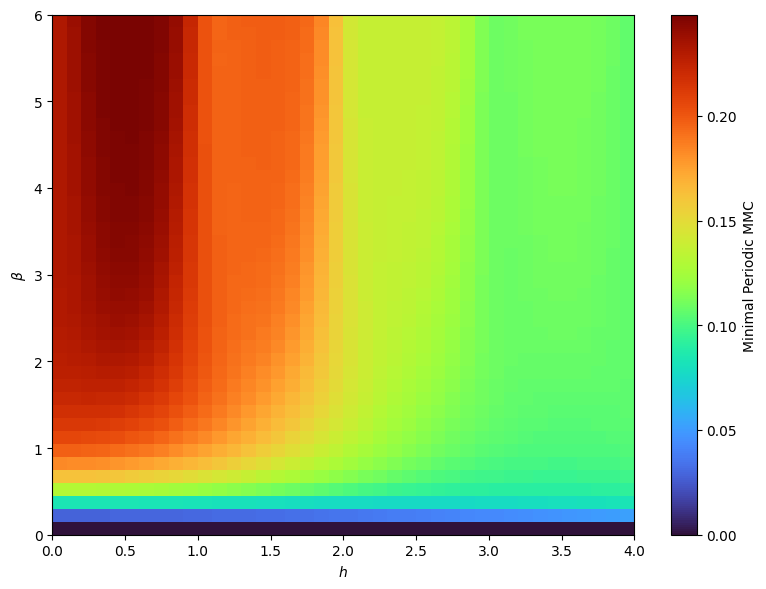

In [ ]:
jax.config.update('jax_log_compiles', True)
# Parameter ranges
h_vals = np.linspace(0, 4, 50)
beta_vals = np.linspace(0, 5, 50)

# Number of steps to include in the cumulative MMC
Nsteps = 50


shape = (4, 4)
N = math.prod(shape)
p0 = np.ones((1 << N)) / (1 << N)
p0_jax = jnp.asarray(p0, dtype=jnp.float32)

graph = make_interaction_graph(shape=shape, J=1.0)
graph_jax = tuple(jnp.asarray(x) for x in graph)

beta_vals = jnp.asarray(beta_vals, dtype=jnp.float32)
h_vals = jnp.asarray(h_vals, dtype=jnp.float32)

@jax.jit
def pmmc_eval(beta, h):
  return pmmc_kernel(p0_jax, graph_jax, beta, h, Nsteps)

@jax.jit
def pmmc_row(beta, h_vals):
  return jax.lax.map(lambda h: pmmc_eval(beta, h), h_vals)

_ = pmmc_eval(beta_vals[0], h_vals[0]).block_until_ready()  # one compile

heatmap = np.empty((len(beta_vals), len(h_vals)), dtype=np.float32)
for i, beta in enumerate(beta_vals):
  heatmap[i] = np.asarray(pmmc_row(beta, h_vals))

# for i, beta in enumerate(beta_vals):
#   for j, h in enumerate(h_vals):
#     heatmap[i, j] = pmmc_eval(beta, h)

# inner_vmap = jax.vmap(pmmc_eval, in_axes=(None, 0))
# grid_vmap = jax.vmap(inner_vmap, in_axes=(0, None))

# heatmap = grid_vmap(beta_vals, h_vals)


# for i, beta in enumerate(beta_vals):
#   for j, h in enumerate(h_vals):
#     G = make_glauber(h, beta)
#     # cumulative MMC
#     heatmap[i, j] = pmmc2(p0, G, Nsteps)
    # print(f"Finished beta = {beta:.2f}")

fig, ax = plt.subplots(1, 1, figsize=(8,6), squeeze=True)
ax.imshow(
  heatmap,
  origin='lower',
  extent=[h_vals[0], h_vals[-1], beta_vals[0], beta_vals[-1]],
  aspect='auto',
  cmap='turbo'
)
ax.set(xlabel=r"$h$", ylabel=r"$\beta$")
plt.colorbar(label=r"Minimal Periodic MMC")
plt.tight_layout()
plt.show()

In [ ]:
# ---- params
J = 1.0
shape = (3, 3)
N = math.prod(shape)
nstates = (1 << N)
p0 = 1 / nstates * np.ones(nstates)

# ---- test

t0 = perf_counter()
# 2x2 Ising model (16 states)
G = generate_glauber_matrix(
  shape=shape,
  J=J,
  h=0.1,
  beta=1.0
)

print(G.shape)
# (16,16)
print(np.allclose(G.sum(axis=0), 1))
# True
print(perf_counter()-t0)


t0 = perf_counter()
G2 = generate_glauber_matrix_bits(
  shape=shape,
  J=J,
  h=0.1,
  beta=1.0
)
print(G2.shape)
# (16,16)

print(np.allclose(G.sum(axis=0), 1))
# True
print(perf_counter()-t0)

print(np.allclose((G2 - G).sum(), 0))



print()
num_times = 1000
t0 = perf_counter()
for _ in range(num_times):
  G = generate_glauber_matrix(
    shape=shape,
    J=J,
    h=0.1,
    beta=1.0
  )
print((perf_counter()-t0)/num_times)


t0 = perf_counter()
for _ in range(num_times):
  G = generate_glauber_matrix_bits(
    shape=shape,
    J=J,
    h=0.1,
    beta=1.0
  )
print((perf_counter()-t0)/num_times)

# Distribution after 10 Glauber updates
Nsteps = 10

p20 = matrix_power(G, Nsteps) @ p0

plt.bar(range(nstates),p0)
plt.bar(range(nstates),p20)

max_steps = 200
for beta in np.linspace(0,3,10):
  G = generate_glauber_matrix(shape=shape, J=J, h=0.1, beta=beta)
  mmc = [pmmc(p0, G, n) for n in range(1, max_steps)]
  plt.plot(mmc, label=rf'$\beta = {beta}$')
  # print(beta)

plt.legend()
plt.show()

for h in np.linspace(0,4,10):
  G = generate_glauber_matrix(shape=shape, J=J, h=h, beta=0.5)
  mmc = [pmmc(p0, G, n) for n in range(1, 50)]
  plt.plot(mmc, label=rf'$h = {round(h,1)}$')
  # print(h)

plt.legend()
plt.show()

In [ ]:
# Parameter ranges
h_vals = np.linspace(0, 4, 40)
beta_vals = np.linspace(0, 6, 40)

# Number of steps to include in the cumulative MMC
Nsteps = 10

heatmap = np.zeros((len(beta_vals), len(h_vals)))

shape = (3, 3)
N = math.prod(shape)
p0 = np.ones((1 << N)) / (1 << N)


make_glauber = lambda h, beta: generate_glauber_matrix(
  shape=shape, J=1.0, h=h, beta=beta
)

make_glauber = lambda h, beta: generate_glauber_matrix_bits(
  shape=shape, J=1.0, h=h, beta=beta
)


for i, beta in enumerate(beta_vals):
  for j, h in enumerate(h_vals):
    G = make_glauber(h, beta)
    # cumulative MMC
    heatmap[i, j] = pmmc2(p0, G, Nsteps)
    # print(f"Finished beta = {beta:.2f}")

plt.figure(figsize=(8,6))
plt.imshow(
    heatmap,
    origin='lower',
    extent=[h_vals[0], h_vals[-1], beta_vals[0], beta_vals[-1]],
    aspect='auto',
    cmap='turbo'
)
plt.xlabel(r"$h$")
plt.ylabel(r"$\beta$")
plt.colorbar(label=r"Minimal Periodic MMC")
plt.tight_layout()
plt.show()

In [ ]:
beta=3.0

G, states, energies = generate_glauber_matrix(
            shape=(2,2),
            J=0.1,
            h=0.1,
            beta=beta
        )

gibbs = [np.exp(-beta*energies[i])/sum(np.exp(-beta*energies)) for i in range(len(energies))]
uniform = 1/len(energies)*np.ones_like(energies)
cross = H(uniform) + H(uniform, gibbs)

print(H(uniform, gibbs))

plt.bar(energies, gibbs)
len(energies)

def analyze_islands(G, tol=1e-16):
    """
    Analyzes a column-stochastic matrix G for islands.
    G[y, x] = P(x -> y)
    """
    # Method 1: Count eigenvalues equal to 1.0
    eigenvalues = np.linalg.eigvals(G)
    num_islands_spectral = np.sum(np.isclose(eigenvalues, 1.0, atol=tol))
    return num_islands_spectral

analyze_islands(G)

In [ ]:
import numpy as np

# 1. Define the transition matrix P
# P[i, j] represents the probability of transitioning from state i to state j.
# The asymmetry ensures a broken detailed balance (driving force).
P = np.array([
    [0.1, 0.7, 0.2],  # From state 0 to 0, 1, 2
    [0.1, 0.2, 0.7],  # From state 1 to 0, 1, 2
    [0.6, 0.1, 0.3]   # From state 2 to 0, 1, 2
])

# Ensure each row sums to 1.0 (valid probability distribution)
assert np.allclose(P.sum(axis=1), 1.0), "Rows must sum to 1"

# 2. Initialize the system state probability distribution (rho)
# We can start with all probability concentrated in state 0
rho = np.array([1.0, 0.0, 0.0])

# 3. Define iterative evolution parameters
tolerance = 1e-10
max_steps = 1000

